In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#config tampilan grafik
sns.set_theme(style="whitegrid")
%matplotlib inline

#load dataset
df = pd.read_csv('../data/fastfood_marketing.csv')

#tampilkan 5 baris data pertama
df.head()


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [5]:
#informasi tipe data dan missing values
print("=== INFO DATASET ===")
df.info()

print("\n===JUMLAH MISSING VALUES===")
print(df.isnull() .sum())

print("\n=== JUMLAH DATA DUPLIKAT ===")
print(f"Total Duplikat: {df.duplicated() .sum()}")


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB

===JUMLAH MISSING VALUES===
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

=== JUMLAH DATA DUPLIKAT ===
Total Duplikat: 0


In [7]:
#nilai kolom promosion .
df['Promotion_Name'] = 'Promotion' + df['Promotion'] .astype(str)

#dekskriptif statistik variable numerik
print("=== STATISTIK DESKRIPTIF ===")
display(df.describe())

#distibusi jumlah data per jenis
print("\n=== JUMLAH OBSERVASI PER PROMOSI ===")
print(df['Promotion_Name'].value_counts())


=== STATISTIK DESKRIPTIF ===


,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000



=== JUMLAH OBSERVASI PER PROMOSI ===
Promotion_Name
Promotion3    188
Promotion2    188
Promotion1    172
Name: count, dtype: int64


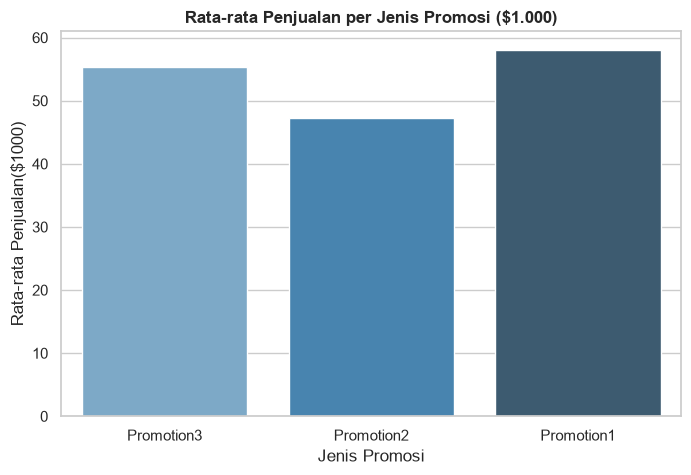

,Promotion_Name,mean,median,std,count
0,Promotion1,58.099012,55.385,16.553782,172
1,Promotion2,47.329415,45.385,15.108955,188
2,Promotion3,55.364468,51.165,16.766231,188


In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df, 
    x='Promotion_Name', 
    y='SalesInThousands', hue='Promotion_Name',
    estimator=np.mean, 
    errorbar=None, 
    palette='Blues_d',
    legend=False
)
plt.title('Rata-rata Penjualan per Jenis Promosi ($1.000)', fontsize=12, fontweight='bold')
plt.xlabel('Jenis Promosi')
plt.ylabel('Rata-rata Penjualan($1000)')
plt.show()

#ringkasan angka
sales_summary = df.groupby('Promotion_Name')['SalesInThousands'].agg(['mean', 'median', 'std', 'count']).reset_index()
display(sales_summary)

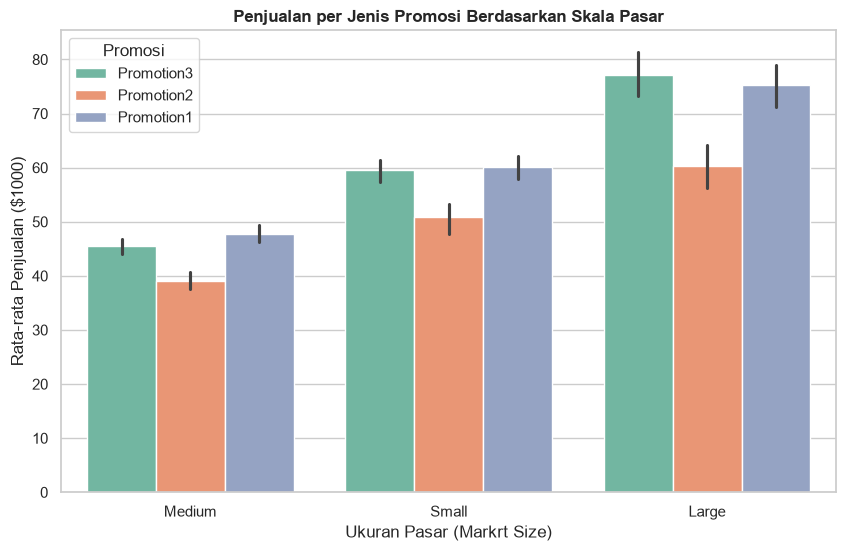

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='MarketSize', y='SalesInThousands', hue='Promotion_Name', palette='Set2')
plt.title('Penjualan per Jenis Promosi Berdasarkan Skala Pasar', fontsize=12, fontweight='bold')
plt.xlabel('Ukuran Pasar (Markrt Size)')
plt.ylabel('Rata-rata Penjualan ($1000)')
plt.legend(title='Promosi')
plt.show()

In [18]:
import scipy.stats as stats

# Kelompok penjualan per promosi 
p1 = df[df['Promotion'] == 1]['SalesInThousands']
p2 = df[df['Promotion'] == 2]['SalesInThousands']
p3 = df[df['Promotion'] == 3]['SalesInThousands']

# Uji One-Way ANOVA
f_stat, p_val = stats.f_oneway(p1, p2, p3)

print(f"=== UJI HYPOTHESIS TESTING (ONE-WAY ANOVA) ===")
print(f"F-Statistic : {f_stat: .4f}")
print(f"P-Value     : {p_val: .4e}")

if p_val < 0.05:
    print("\nKesimpulan: Ada perbedaan signifikan secara statistik antara performa promosi 1, 2, dan 3 (p < 0.05).")
else:
    print("\nKesimpulan: Tidak ada perbedaan signifikan secara statistik antar promosi (p >= 0.05).")


=== UJI HYPOTHESIS TESTING (ONE-WAY ANOVA) ===
F-Statistic :  21.9535
P-Value     :  6.7658e-10

Kesimpulan: Ada perbedaan signifikan secara statistik antara performa promosi 1, 2, dan 3 (p < 0.05).
